In [1]:
print("notebook ready")

notebook ready


In [37]:
import pandas as pd
from pathlib import Path
import numpy as np


In [25]:
GDP_PATH = "C:/Users/Dell/OneDrive/Documents/global inequality analysis/data/raw/API_NY.GDP.PCAP.CD_DS2_en_csv_v2_31.csv"
GINI_PATH = "C:/Users/Dell/OneDrive/Documents/global inequality analysis/data/raw/API_SI.POV.GINI_DS2_en_csv_v2_35.csv"

gdp = pd.read_csv(GDP_PATH, skiprows=4)
gini = pd.read_csv(GINI_PATH, skiprows=4)

print("GDP shape:", gdp.shape)
print("GINI shape:", gini.shape)

gdp.head()
gini.head()

GDP shape: (266, 70)
GINI shape: (266, 70)


,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2016,2017,2018,2019,2020,2021,2022,2023,2024,Unnamed: 69
0,Aruba,ABW,Gini index,SI.POV.GINI,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Africa Eastern and Southern,AFE,Gini index,SI.POV.GINI,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Afghanistan,AFG,Gini index,SI.POV.GINI,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Africa Western and Central,AFW,Gini index,SI.POV.GINI,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Angola,AGO,Gini index,SI.POV.GINI,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,51.3,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [26]:
from pathlib import Path
print(Path.cwd())
gdp_long = gdp.melt(
    id_vars=["Country Name", "Country Code"],
    var_name="Year",
    value_name="GDP_per_capita"
)

gdp_long.head()


c:\Users\Dell\OneDrive\Documents\global inequality analysis\notebooks


,Country Name,Country Code,Year,GDP_per_capita
0,Aruba,ABW,Indicator Name,GDP per capita (current US$)
1,Africa Eastern and Southern,AFE,Indicator Name,GDP per capita (current US$)
2,Afghanistan,AFG,Indicator Name,GDP per capita (current US$)
3,Africa Western and Central,AFW,Indicator Name,GDP per capita (current US$)
4,Angola,AGO,Indicator Name,GDP per capita (current US$)


In [27]:
gini_long = gini.melt(
    id_vars=["Country Name", "Country Code"],
    var_name="Year",
    value_name="Gini_index"
)

gini_long.head()


,Country Name,Country Code,Year,Gini_index
0,Aruba,ABW,Indicator Name,Gini index
1,Africa Eastern and Southern,AFE,Indicator Name,Gini index
2,Afghanistan,AFG,Indicator Name,Gini index
3,Africa Western and Central,AFW,Indicator Name,Gini index
4,Angola,AGO,Indicator Name,Gini index


In [28]:
gdp_long["Year"] = pd.to_numeric(gdp_long["Year"], errors="coerce")
gini_long["Year"] = pd.to_numeric(gini_long["Year"], errors="coerce")


In [29]:
gdp_long.shape

gini_long.shape



(18088, 4)

In [30]:
merged = pd.merge(
    gdp_long,
    gini_long,
    on=["Country Name", "Country Code", "Year"],
    how="inner"
)

merged.head()


,Country Name,Country Code,Year,GDP_per_capita,Gini_index
0,Aruba,ABW,NaN,GDP per capita (current US$),Gini index
1,Aruba,ABW,NaN,GDP per capita (current US$),SI.POV.GINI
2,Aruba,ABW,NaN,GDP per capita (current US$),NaN
3,Africa Eastern and Southern,AFE,NaN,GDP per capita (current US$),Gini index
4,Africa Eastern and Southern,AFE,NaN,GDP per capita (current US$),SI.POV.GINI


In [31]:
merged = merged[(merged["Year"] >= 2000) & (merged["Year"] <= 2022)]


In [32]:
merged = merged.dropna(subset=["GDP_per_capita", "Gini_index"])


In [33]:
print("Final merged shape:", merged.shape)
merged.head()



Final merged shape: (1764, 5)


,Country Name,Country Code,Year,GDP_per_capita,Gini_index
12240,Angola,AGO,2000.0,563.733796,51.9
12245,Argentina,ARG,2000.0,7637.014892,51.0
12250,Austria,AUT,2000.0,24487.297469,29.0
12253,Belgium,BEL,2000.0,23098.886508,33.1
12256,Bangladesh,BGD,2000.0,396.67073,33.4


In [34]:
merged["Year"] = merged["Year"].astype(int)


In [35]:
merged["Year"].head()


12240    2000
12245    2000
12250    2000
12253    2000
12256    2000
Name: Year, dtype: int32

In [38]:



merged["GDP_per_capita"] = pd.to_numeric(merged["GDP_per_capita"], errors="coerce")
merged["Gini_index"] = pd.to_numeric(merged["Gini_index"], errors="coerce")

merged = merged.dropna(subset=["GDP_per_capita", "Gini_index"])
merged = merged[merged["GDP_per_capita"] > 0]

merged[["GDP_per_capita", "Gini_index"]].dtypes
merged["GDP_per_capita"].describe()

merged["log_GDP"] = np.log(merged["GDP_per_capita"])
merged[["GDP_per_capita", "log_GDP"]].head()



,GDP_per_capita,log_GDP
12240,563.733796,6.334582
12245,7637.014892,8.940762
12250,24487.297469,10.105910
12253,23098.886508,10.047540
12256,396.670730,5.983107


In [39]:
corr = merged["log_GDP"].corr(merged["Gini_index"])
corr


-0.3695495984197416

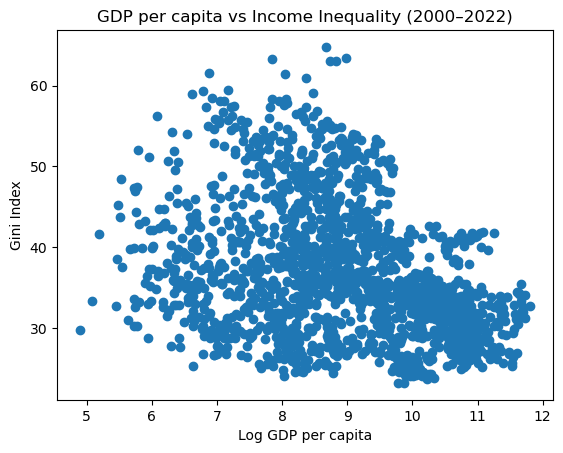

In [40]:
import matplotlib.pyplot as plt

plt.figure()
plt.scatter(merged["log_GDP"], merged["Gini_index"])
plt.xlabel("Log GDP per capita")
plt.ylabel("Gini Index")
plt.title("GDP per capita vs Income Inequality (2000–2022)")
plt.show()


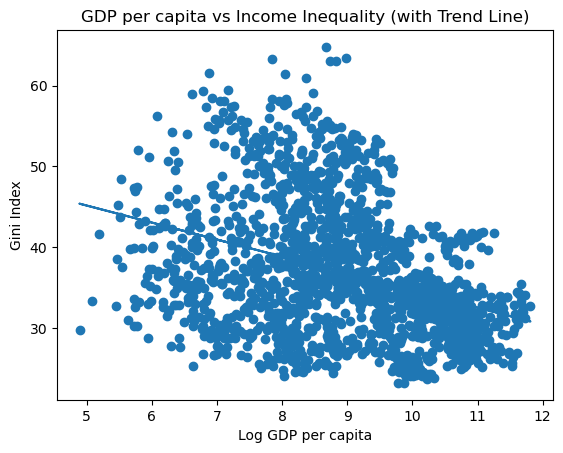

In [41]:

m, b = np.polyfit(merged["log_GDP"], merged["Gini_index"], 1)

plt.figure()
plt.scatter(merged["log_GDP"], merged["Gini_index"])
plt.plot(merged["log_GDP"], m*merged["log_GDP"] + b)
plt.xlabel("Log GDP per capita")
plt.ylabel("Gini Index")
plt.title("GDP per capita vs Income Inequality (with Trend Line)")
plt.show()


In [42]:
#find the max year
merged["Year"].max()


2022

In [43]:
#filter the year
latest_year = merged["Year"].max()

latest = merged[merged["Year"] == latest_year].copy()

latest.shape
latest.head()


,Country Name,Country Code,Year,GDP_per_capita,Gini_index,log_GDP
18097,Argentina,ARG,2022,13962.189409,40.7,9.544108
18098,Armenia,ARM,2022,6571.974455,27.9,8.790570
18102,Austria,AUT,2022,52336.772522,30.9,10.865455
18105,Belgium,BEL,2022,50605.749668,26.4,10.831820
18108,Bangladesh,BGD,2022,2716.485928,30.9,7.907094


In [44]:

# make sure numeric
latest["GDP_per_capita"] = pd.to_numeric(latest["GDP_per_capita"], errors="coerce")
latest["Gini_index"] = pd.to_numeric(latest["Gini_index"], errors="coerce")

# keep valid rows for log
latest = latest.dropna(subset=["GDP_per_capita", "Gini_index"])
latest = latest[latest["GDP_per_capita"] > 0]

# create log GDP
latest["log_GDP"] = np.log(latest["GDP_per_capita"])
latest[["GDP_per_capita", "log_GDP", "Gini_index"]].head()



,GDP_per_capita,log_GDP,Gini_index
18097,13962.189409,9.544108,40.7
18098,6571.974455,8.790570,27.9
18102,52336.772522,10.865455,30.9
18105,50605.749668,10.831820,26.4
18108,2716.485928,7.907094,30.9


In [45]:
#recalculate the correlation
corr_latest = latest["log_GDP"].corr(latest["Gini_index"])
corr_latest


-0.25200981074291867

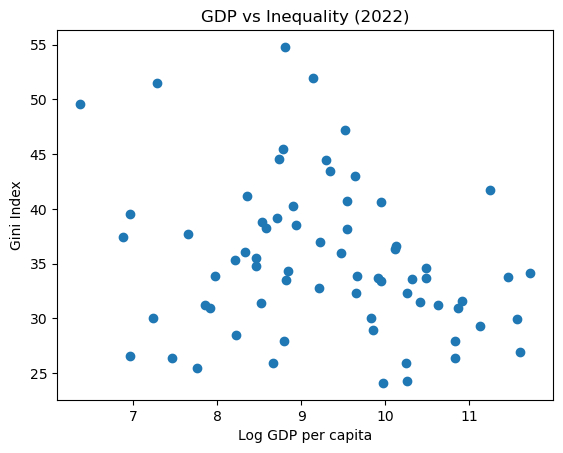

In [46]:
#make a scatter plot of the new data
import matplotlib.pyplot as plt


plt.figure()
plt.scatter(latest["log_GDP"], latest["Gini_index"])
plt.xlabel("Log GDP per capita")
plt.ylabel("Gini Index")
plt.title(f"GDP vs Inequality ({latest_year})")
plt.show()


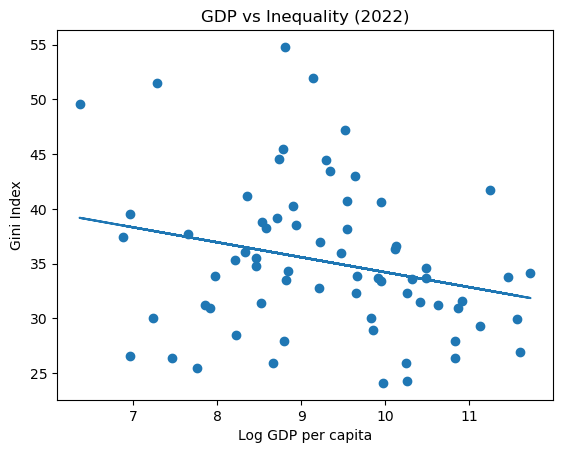

In [47]:
m, b = np.polyfit(latest["log_GDP"], latest["Gini_index"], 1)

plt.figure()
plt.scatter(latest["log_GDP"], latest["Gini_index"])
plt.plot(latest["log_GDP"], m*latest["log_GDP"] + b)
plt.xlabel("Log GDP per capita")
plt.ylabel("Gini Index")
plt.title(f"GDP vs Inequality ({latest_year})")
plt.show()


In [48]:
#Regional comparison
meta = pd.read_csv("C:/Users/Dell/OneDrive/Documents/global inequality analysis/data/raw/Metadata_Country_API_NY.GDP.PCAP.CD_DS2_en_csv_v2_31.csv")
meta.head()

,Country Code,Region,IncomeGroup,SpecialNotes,TableName,Unnamed: 5
0,ABW,Latin America & Caribbean,High income,NaN,Aruba,NaN
1,AFE,NaN,NaN,"26 countries, stretching from the Red Sea in t...",Africa Eastern and Southern,NaN
2,AFG,Middle East & North Africa,Low income,The reporting period for national accounts dat...,Afghanistan,NaN
3,AFW,NaN,NaN,"22 countries, stretching from the westernmost ...",Africa Western and Central,NaN
4,AGO,Sub-Saharan Africa,Lower middle income,The World Bank systematically assesses the app...,Angola,NaN


In [49]:
#clean the meta data
# Keep only needed columns
meta_clean = meta[["Country Code", "Region", "IncomeGroup"]].copy()

# Remove rows where Region is missing 
meta_clean = meta_clean.dropna(subset=["Region"])

meta_clean.head()


,Country Code,Region,IncomeGroup
0,ABW,Latin America & Caribbean,High income
2,AFG,Middle East & North Africa,Low income
4,AGO,Sub-Saharan Africa,Lower middle income
5,ALB,Europe & Central Asia,Upper middle income
6,AND,Europe & Central Asia,High income


In [50]:
#merge region to the latest dataset
latest = pd.merge(
    latest,
    meta_clean,
    on="Country Code",
    how="left"
)

latest.head()


,Country Name,Country Code,Year,GDP_per_capita,Gini_index,log_GDP,Region,IncomeGroup
0,Argentina,ARG,2022,13962.189409,40.7,9.544108,Latin America & Caribbean,Upper middle income
1,Armenia,ARM,2022,6571.974455,27.9,8.790570,Europe & Central Asia,Upper middle income
2,Austria,AUT,2022,52336.772522,30.9,10.865455,Europe & Central Asia,High income
3,Belgium,BEL,2022,50605.749668,26.4,10.831820,Europe & Central Asia,High income
4,Bangladesh,BGD,2022,2716.485928,30.9,7.907094,South Asia,Lower middle income


In [51]:
#quickcheck
latest["Region"].value_counts()


Region
Europe & Central Asia         35
Latin America & Caribbean     14
Sub-Saharan Africa             6
East Asia & Pacific            5
South Asia                     4
Middle East & North Africa     4
North America                  1
Name: count, dtype: int64

In [52]:
#compare average inequality with by region
region_summary = latest.groupby("Region")[["Gini_index", "GDP_per_capita"]].mean()

region_summary


,Gini_index,GDP_per_capita
Region,,
East Asia & Pacific,34.660000,6750.401191
Europe & Central Asia,31.734286,33685.502084
Latin America & Caribbean,43.457143,9766.748707
Middle East & North Africa,32.825000,11266.530317
North America,41.700000,76657.248884
South Asia,28.725000,2540.293141
Sub-Saharan Africa,41.433333,2598.239040


In [53]:
import statsmodels.api as sm

In [54]:
#preparing the reggersion data
X = latest["log_GDP"]
y = latest["Gini_index"]

X = sm.add_constant(X)  # adds intercept

model = sm.OLS(y, X).fit()

model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:             Gini_index   R-squared:                       0.064
Model:                            OLS   Adj. R-squared:                  0.050
Method:                 Least Squares   F-statistic:                     4.544
Date:                Fri, 20 Feb 2026   Prob (F-statistic):             0.0367
Time:                        22:22:37   Log-Likelihood:                -228.25
No. Observations:                  69   AIC:                             460.5
Df Residuals:                      67   BIC:                             465.0
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         47.8812      6.003      7.976      0.000      35.899      59.863
log_GDP       -1.3670      0.641     -2.132      0.037      -2.647      -0.087
==============================================================================
Omnibus:                        4.161   Durbin-Watson:                   1.698
Prob(Omnibus):                  0.125   Jarque-Bera (JB):                3.473
Skew:                           0.538   Prob(JB):                        0.176
Kurtosis:                       3.227   Cond. No.                         70.3
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [55]:
#export the cleaned crossed section data
final_dataset = latest[
    ["Country Name", "Country Code", "Region", "IncomeGroup",
     "GDP_per_capita", "log_GDP", "Gini_index"]
].copy()

final_dataset.head()

,Country Name,Country Code,Region,IncomeGroup,GDP_per_capita,log_GDP,Gini_index
0,Argentina,ARG,Latin America & Caribbean,Upper middle income,13962.189409,9.544108,40.7
1,Armenia,ARM,Europe & Central Asia,Upper middle income,6571.974455,8.790570,27.9
2,Austria,AUT,Europe & Central Asia,High income,52336.772522,10.865455,30.9
3,Belgium,BEL,Europe & Central Asia,High income,50605.749668,10.831820,26.4
4,Bangladesh,BGD,South Asia,Lower middle income,2716.485928,7.907094,30.9


In [ ]:
#export the cleaned data
final_dataset.to_csv("../data/clean/global_inequality_2022.csv", index=False)